<img src="https://raw.githubusercontent.com/carlosfab/blog-sigmoidal/main/_assets/logo_sigmoidal.png" alt="Sigmoidal" width="400">

# Análise de ECG com Python

Notebook público do artigo publicado no blog [Sigmoidal](https://sigmoidal.ai).

---

## O sinal do coração

O **eletrocardiograma (ECG)** registra a atividade elétrica do coração ao longo do tempo. Cada batimento produz uma sequência característica de deflexões: a **onda P** (despolarização atrial), o **complexo QRS** (despolarização ventricular, o pico mais alto e nítido) e a **onda T** (repolarização ventricular).

A leitura automática desse traçado combina **processamento de sinais** e **ciência de dados**: filtrar o ruído, localizar os batimentos, medir intervalos e, a partir desses atributos, treinar modelos capazes de distinguir padrões fisiológicos. Neste notebook percorremos essa cadeia completa usando sinais simulados, de modo que os resultados são reproduzíveis sem depender de nenhuma base clínica externa.

## Configuração do ambiente

Usamos `neurokit2` para simular e processar o ECG, `scikit-learn` para a etapa de classificação e o par `numpy`/`matplotlib` para cálculo numérico e visualização. As sementes aleatórias ficam fixas para garantir que os números aqui reproduzidos coincidam com os do artigo.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import neurokit2 as nk

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

SEED = 42
np.random.seed(SEED)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.figsize": (11, 4),
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
})

## Como é a forma de onda de um ECG?

Começamos com um sinal ideal. A função `nk.ecg_simulate` gera um traçado sintético a partir de parâmetros fisiológicos: duração, frequência de amostragem e frequência cardíaca média. Simulamos 10 segundos a 250 Hz, com cerca de 70 batimentos por minuto.

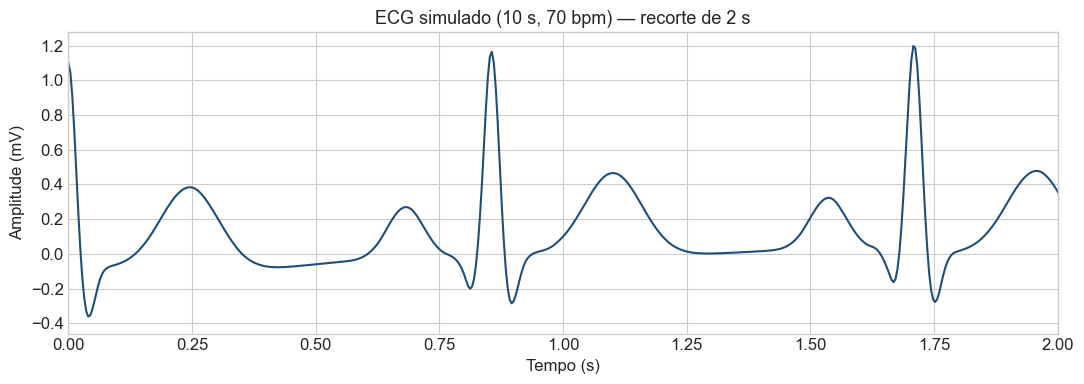

In [2]:
sampling_rate = 250
duration = 10  # segundos

ecg_limpo = nk.ecg_simulate(
    duration=duration,
    sampling_rate=sampling_rate,
    heart_rate=70,
    random_state=SEED,
)

tempo = np.arange(len(ecg_limpo)) / sampling_rate

# Recorte de ~2 s para destacar as ondas P, QRS e T de um batimento
plt.figure()
plt.plot(tempo, ecg_limpo, color="#1f4e79")
plt.xlim(0, 2)
plt.title("ECG simulado (10 s, 70 bpm) — recorte de 2 s")
plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude (mV)")
plt.tight_layout()
plt.show()

O recorte deixa visível o padrão que se repete a cada batimento: uma pequena elevação inicial (**onda P**), o pico estreito e proeminente (**complexo QRS**) e a ondulação seguinte (**onda T**). É essa assinatura que os algoritmos aprendem a localizar.

## O sinal real nunca chega limpo

Um traçado adquirido na prática carrega interferências. Duas são particularmente comuns: a **flutuação da linha de base** (_baseline wander_), oscilação lenta causada pela respiração e pelo movimento dos eletrodos, e o **ruído de rede elétrica** em torno de 50 a 60 Hz. Somamos as duas componentes ao sinal ideal para reproduzir essa condição.

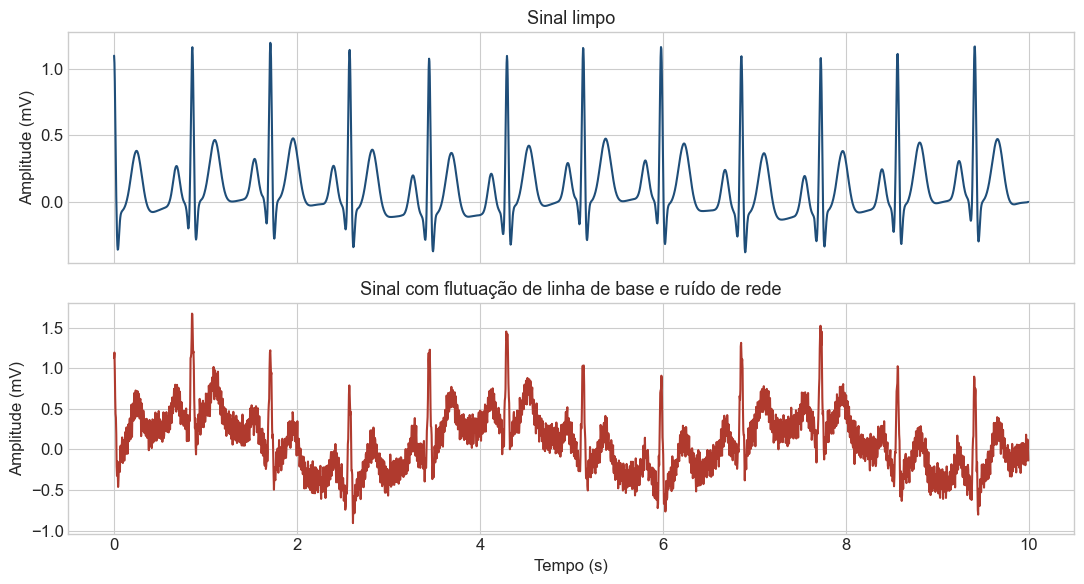

In [3]:
# Flutuação lenta da linha de base (~0,3 Hz)
baseline_wander = 0.4 * np.sin(2 * np.pi * 0.3 * tempo)

# Interferência de rede elétrica (60 Hz)
ruido_rede = 0.15 * np.sin(2 * np.pi * 60 * tempo)

# Ruído branco de baixa amplitude
ruido_branco = np.random.normal(0, 0.05, size=len(ecg_limpo))

ecg_ruidoso = ecg_limpo + baseline_wander + ruido_rede + ruido_branco

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(tempo, ecg_limpo, color="#1f4e79")
axes[0].set_title("Sinal limpo")
axes[0].set_ylabel("Amplitude (mV)")
axes[1].plot(tempo, ecg_ruidoso, color="#b03a2e")
axes[1].set_title("Sinal com flutuação de linha de base e ruído de rede")
axes[1].set_xlabel("Tempo (s)")
axes[1].set_ylabel("Amplitude (mV)")
plt.tight_layout()
plt.show()

A flutuação da linha de base desloca todo o traçado para cima e para baixo, enquanto o ruído de rede adiciona uma textura de alta frequência sobre as ondas. Sem tratamento, essas distorções comprometem tanto a inspeção visual quanto a detecção automática dos batimentos.

## Recuperando o sinal com filtragem

A função `nk.ecg_clean` aplica uma cadeia de filtros que remove a componente lenta da linha de base e atenua as altas frequências, preservando a morfologia das ondas. Comparamos o sinal ruidoso com o resultado da limpeza.

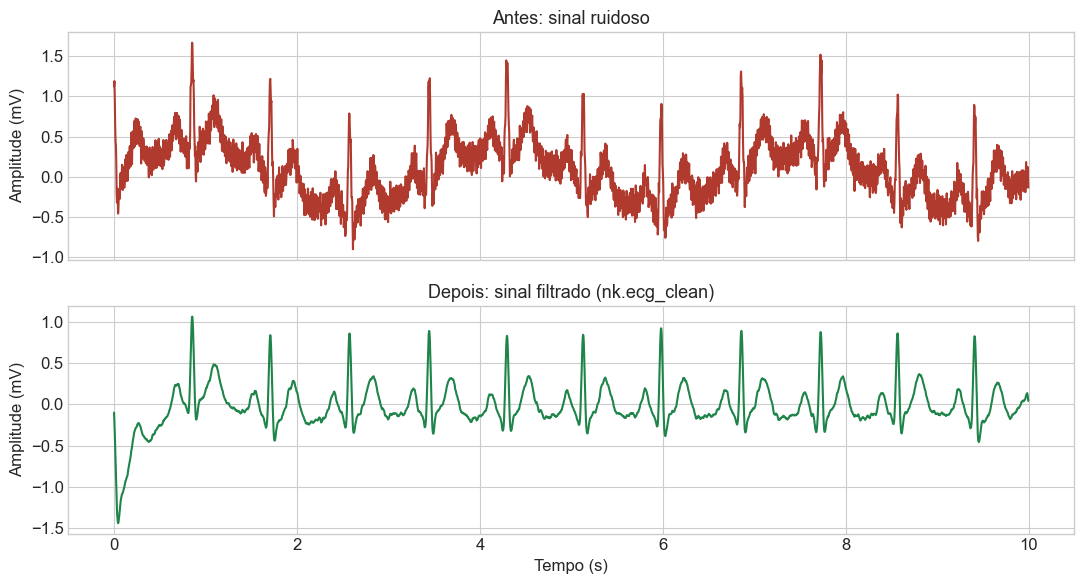

In [4]:
ecg_filtrado = nk.ecg_clean(ecg_ruidoso, sampling_rate=sampling_rate)

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(tempo, ecg_ruidoso, color="#b03a2e")
axes[0].set_title("Antes: sinal ruidoso")
axes[0].set_ylabel("Amplitude (mV)")
axes[1].plot(tempo, ecg_filtrado, color="#1e8449")
axes[1].set_title("Depois: sinal filtrado (nk.ecg_clean)")
axes[1].set_xlabel("Tempo (s)")
axes[1].set_ylabel("Amplitude (mV)")
plt.tight_layout()
plt.show()

O traçado filtrado volta a oscilar em torno de uma linha de base estável e recupera os complexos QRS com nitidez. É sobre esse sinal, e não sobre o bruto, que executamos as etapas seguintes.

## Onde estão os batimentos?

O ponto de referência de cada batimento é o **pico R**, o vértice do complexo QRS. Localizá-lo é o passo que sustenta praticamente todas as medidas clínicas derivadas do ECG. A função `nk.ecg_peaks` implementa um detector baseado na abordagem clássica de análise do QRS e retorna as posições, em amostras, de cada pico R.

Número de picos R detectados: 11


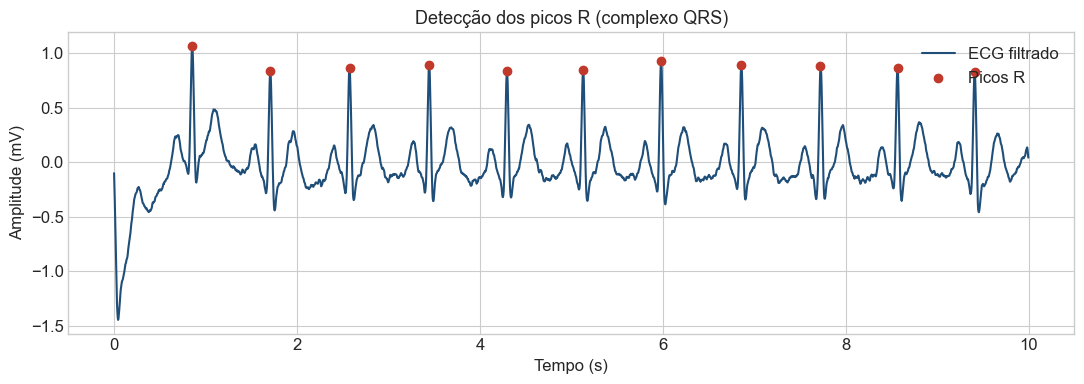

In [5]:
sinais, info = nk.ecg_peaks(ecg_filtrado, sampling_rate=sampling_rate)
picos_r = info["ECG_R_Peaks"]

n_picos = len(picos_r)
print(f"Número de picos R detectados: {n_picos}")

plt.figure()
plt.plot(tempo, ecg_filtrado, color="#1f4e79", label="ECG filtrado")
plt.scatter(picos_r / sampling_rate, ecg_filtrado[picos_r],
            color="#c0392b", zorder=5, label="Picos R")
plt.title("Detecção dos picos R (complexo QRS)")
plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude (mV)")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

Cada marcador vermelho corresponde a um batimento identificado. O número de picos em 10 segundos já dá uma primeira estimativa grosseira do ritmo, mas o cálculo formal da frequência vem dos intervalos entre picos consecutivos.

## Da distância entre picos à frequência cardíaca

O **intervalo RR** é o tempo entre dois picos R consecutivos. A frequência cardíaca instantânea, em batimentos por minuto, é o inverso desse intervalo multiplicado por 60:

$$\text{HR} = \frac{60}{\text{RR}}$$

onde $\text{RR}$ é medido em segundos. Convertendo as posições dos picos de amostras para segundos, obtemos a série de intervalos RR e, a partir dela, a frequência instantânea.

Intervalo RR médio: 0.855 s
Frequência cardíaca média: 70.2 bpm


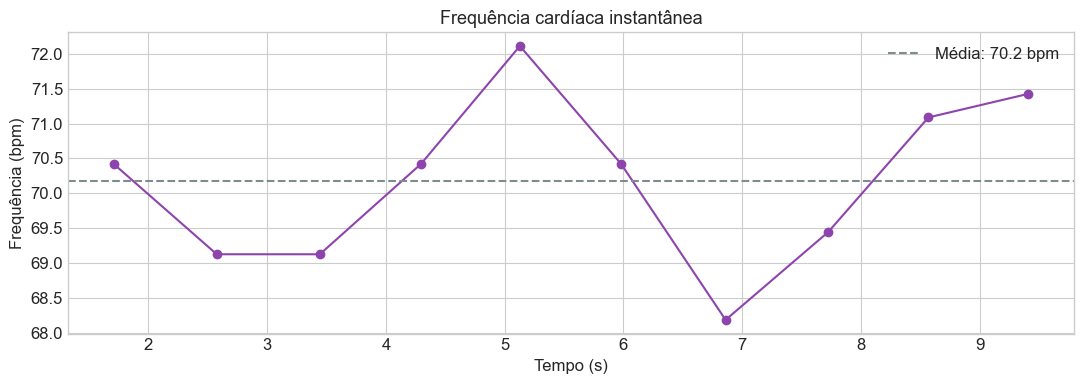

In [6]:
# Intervalos RR em segundos
rr_segundos = np.diff(picos_r) / sampling_rate

# Frequência cardíaca instantânea (bpm)
hr_instantanea = 60 / rr_segundos
hr_media = hr_instantanea.mean()

print(f"Intervalo RR médio: {rr_segundos.mean():.3f} s")
print(f"Frequência cardíaca média: {hr_media:.1f} bpm")

# Tempo de cada batimento (a partir do segundo pico)
tempo_batimentos = picos_r[1:] / sampling_rate

plt.figure()
plt.plot(tempo_batimentos, hr_instantanea, marker="o", color="#8e44ad")
plt.axhline(hr_media, color="#7f8c8d", linestyle="--",
            label=f"Média: {hr_media:.1f} bpm")
plt.title("Frequência cardíaca instantânea")
plt.xlabel("Tempo (s)")
plt.ylabel("Frequência (bpm)")
plt.legend()
plt.tight_layout()
plt.show()

A frequência oscila levemente ao redor da média, refletindo a variação natural entre batimentos. Essa flutuação, longe de ser um defeito da medição, carrega informação fisiológica relevante, quantificada pela análise de variabilidade.

## Quanto o ritmo varia? A variabilidade da frequência cardíaca

A **variabilidade da frequência cardíaca** (_Heart Rate Variability_, HRV) mede como os intervalos RR flutuam ao longo do tempo. Dois índices no domínio do tempo são de uso corrente:

- **SDNN**: desvio-padrão de todos os intervalos RR normais, uma medida global da variabilidade.
- **RMSSD**: raiz quadrada da média dos quadrados das diferenças entre intervalos RR sucessivos, sensível às variações rápidas de curto prazo.

A função `nk.hrv_time` calcula esses índices. O **gráfico de Poincaré**, que dispõe cada intervalo RR contra o seguinte, oferece uma leitura visual dessa dispersão.

SDNN:  14.70 ms
RMSSD: 17.54 ms


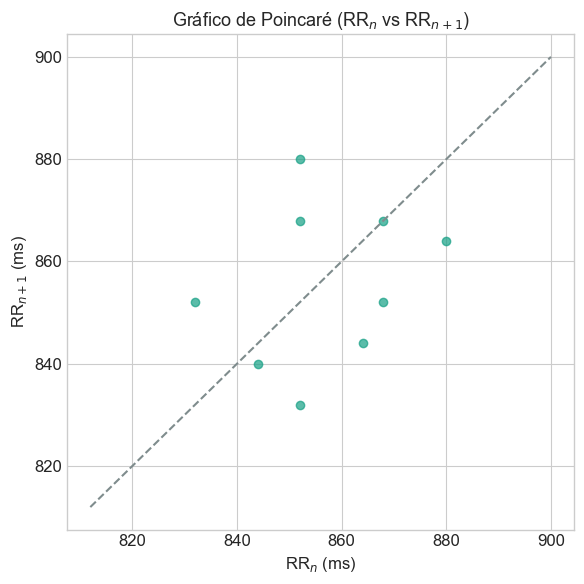

In [7]:
hrv = nk.hrv_time(picos_r, sampling_rate=sampling_rate, show=False)
sdnn = hrv["HRV_SDNN"].iloc[0]
rmssd = hrv["HRV_RMSSD"].iloc[0]

print(f"SDNN:  {sdnn:.2f} ms")
print(f"RMSSD: {rmssd:.2f} ms")

# Gráfico de Poincaré: RR(n) vs RR(n+1), em milissegundos
rr_ms = rr_segundos * 1000
plt.figure(figsize=(6, 6))
plt.scatter(rr_ms[:-1], rr_ms[1:], color="#16a085", alpha=0.7)
lim_min, lim_max = rr_ms.min() - 20, rr_ms.max() + 20
plt.plot([lim_min, lim_max], [lim_min, lim_max],
         color="#7f8c8d", linestyle="--")
plt.title("Gráfico de Poincaré (RR$_n$ vs RR$_{n+1}$)")
plt.xlabel("RR$_n$ (ms)")
plt.ylabel("RR$_{n+1}$ (ms)")
plt.tight_layout()
plt.show()

Pontos próximos à diagonal indicam intervalos sucessivos parecidos entre si, isto é, um ritmo estável. A extensão da nuvem ao longo e ao redor da diagonal traduz, respectivamente, a variabilidade de longo e de curto prazo capturadas por SDNN e RMSSD.

## Classificando padrões de ritmo com aprendizado de máquina

As medidas anteriores descrevem um único registro. O passo natural em ciência de dados é usá-las como **atributos** para um modelo que distingue padrões de ritmo. Simulamos 30 registros de 10 segundos em cada uma de três classes fisiológicas:

- **Bradicardia**: ritmo lento, em torno de 48 bpm.
- **Ritmo normal**: em torno de 72 bpm.
- **Taquicardia**: ritmo acelerado, em torno de 110 bpm.

Cada registro recebe uma pequena variação aleatória de frequência para que as classes não sejam triviais. De cada um extraímos seis atributos: frequência cardíaca média, SDNN, RMSSD e os intervalos RR médio, mínimo e máximo.

In [8]:
def extrair_atributos(ecg, sampling_rate):
    """Extrai atributos de frequência e variabilidade de um registro de ECG."""
    limpo = nk.ecg_clean(ecg, sampling_rate=sampling_rate)
    _, info = nk.ecg_peaks(limpo, sampling_rate=sampling_rate)
    picos = info["ECG_R_Peaks"]

    rr = np.diff(picos) / sampling_rate  # em segundos
    hr = 60 / rr
    rr_ms = rr * 1000

    sdnn = np.std(rr_ms, ddof=1)
    rmssd = np.sqrt(np.mean(np.diff(rr_ms) ** 2))

    return {
        "hr_media": hr.mean(),
        "sdnn": sdnn,
        "rmssd": rmssd,
        "rr_medio": rr.mean(),
        "rr_min": rr.min(),
        "rr_max": rr.max(),
    }


classes = {
    "Bradicardia": 48,
    "Normal": 72,
    "Taquicardia": 110,
}

n_por_classe = 30
rng = np.random.default_rng(SEED)

X, y = [], []
for nome_classe, hr_base in classes.items():
    for _ in range(n_por_classe):
        hr = hr_base + rng.normal(0, 4)  # variação individual
        ecg = nk.ecg_simulate(
            duration=10,
            sampling_rate=sampling_rate,
            heart_rate=hr,
            random_state=int(rng.integers(0, 1_000_000)),
        )
        X.append(list(extrair_atributos(ecg, sampling_rate).values()))
        y.append(nome_classe)

X = np.array(X)
y = np.array(y)
print(f"Total de registros: {len(y)}  |  Atributos por registro: {X.shape[1]}")

Total de registros: 90  |  Atributos por registro: 6


Com a matriz de atributos montada, separamos os dados em treino e teste de forma estratificada e treinamos um **Random Forest**. A árvore aleatória lida bem com poucos atributos numéricos e não exige normalização, o que a torna um ponto de partida sólido.

In [9]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.3, random_state=SEED, stratify=y
)

modelo = RandomForestClassifier(n_estimators=200, random_state=SEED)
modelo.fit(X_treino, y_treino)

y_pred = modelo.predict(X_teste)

acuracia = (y_pred == y_teste).mean()
print(f"Acurácia no conjunto de teste: {acuracia:.3f}\n")
print(classification_report(y_teste, y_pred))

Acurácia no conjunto de teste: 1.000

              precision    recall  f1-score   support

 Bradicardia       1.00      1.00      1.00         9
      Normal       1.00      1.00      1.00         9
 Taquicardia       1.00      1.00      1.00         9

    accuracy                           1.00        27
   macro avg       1.00      1.00      1.00        27
weighted avg       1.00      1.00      1.00        27



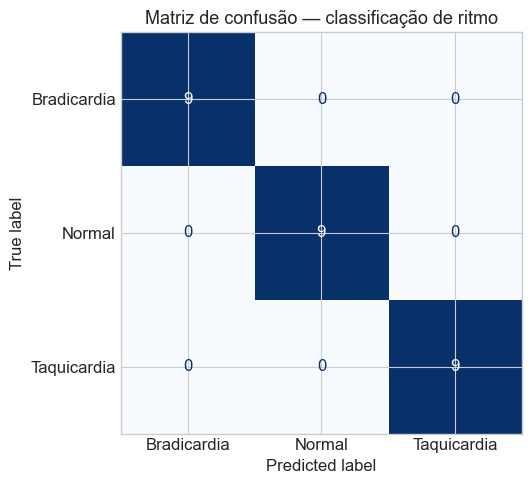

In [10]:
rotulos = ["Bradicardia", "Normal", "Taquicardia"]
cm = confusion_matrix(y_teste, y_pred, labels=rotulos)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rotulos)
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Matriz de confusão — classificação de ritmo")
plt.tight_layout()
plt.show()

A matriz de confusão mostra como o modelo distribui os acertos e os eventuais erros entre as três classes. Como bradicardia, ritmo normal e taquicardia ocupam faixas de frequência bem separadas, a fronteira de decisão baseada em frequência cardíaca e variabilidade é clara, o que se reflete em uma classificação de alta acurácia.

## Takeaways

- **O ECG é um sinal estruturado**: as ondas P, QRS e T se repetem a cada batimento e servem de âncora para toda medida derivada.
- **Filtrar vem antes de medir**: `nk.ecg_clean` remove flutuação de linha de base e ruído de rede, condição para uma detecção de picos confiável.
- **O pico R é o ponto de partida**: localizado o complexo QRS, os intervalos RR levam diretamente à frequência cardíaca pela relação $\text{HR} = 60 / \text{RR}$.
- **A variabilidade carrega informação**: SDNN e RMSSD resumem, respectivamente, a flutuação global e a de curto prazo dos intervalos RR.
- **Atributos simples sustentam classificação**: seis medidas de frequência e variabilidade bastam para um Random Forest separar bradicardia, ritmo normal e taquicardia com alta acurácia.